In [1]:
from tool1 import *
set_seed(42)
device = get_device()
print('device:', device)

device: cpu


xb shape: torch.Size([128, 1, 28, 28])
yb shape: torch.Size([128])


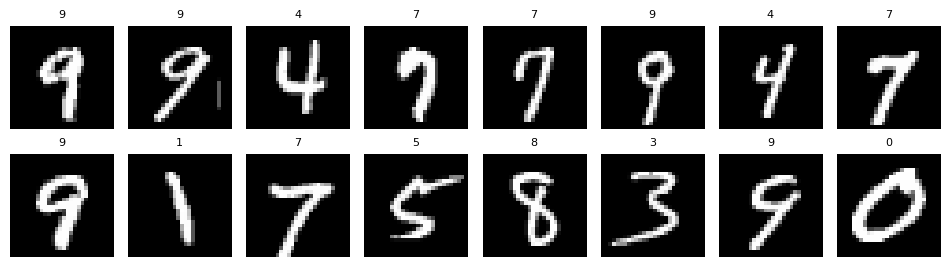

In [5]:
train_loader, test_loader = get_mnist_loaders(batch_size=128)
xb, yb = next(iter(train_loader))
print('xb shape:', xb.shape)
print('yb shape:', yb.shape)
show_image_grid(xb[:16], titles=[int(t) for t in yb[:16]], cols=8)

In [8]:
class MnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)
    
model = MnistModel().to(device)
print('params:', sum(p.numel() for p in model.parameters()))

params: 101770


In [9]:
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
history = train_classifier(model, train_loader, test_loader, opt, loss_fn,
                            epochs=5, device=device)

epoch 1/5 | train 0.4420 | val 0.2812 | acc 0.919
epoch 2/5 | train 0.2388 | val 0.2124 | acc 0.936
epoch 3/5 | train 0.1810 | val 0.1550 | acc 0.955
epoch 4/5 | train 0.1430 | val 0.1332 | acc 0.960
epoch 5/5 | train 0.1198 | val 0.1106 | acc 0.967


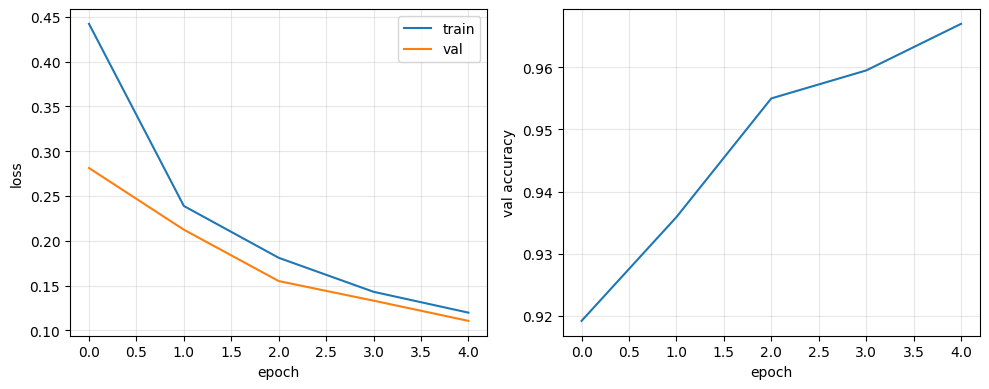

In [12]:
import matplotlib.pyplot as plt
fix, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history['train_loss'], label='train'); 
axes[0].plot(history['val_loss'], label='val')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); 
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history['val_acc']); 
axes[1].set_xlabel('epoch'); 
axes[1].set_ylabel('val accuracy'); axes[1].grid(alpha=0.3)
plt.tight_layout()

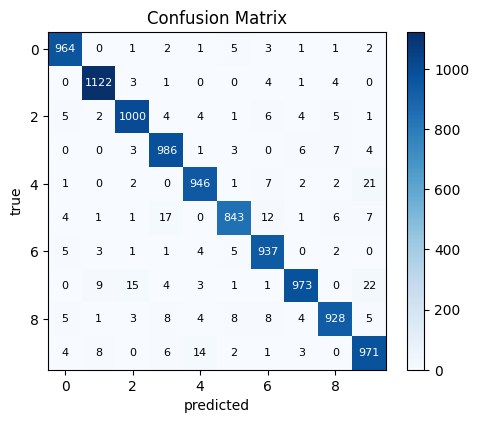

In [13]:
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        out = model(xb.to(device))
        y_pred.append(out.argmax(dim=1).cpu())
        y_true.append(yb)
y_true = torch.cat(y_true).numpy()
y_pred = torch.cat(y_pred).numpy()

cm = np.zeros((10, 10), dtype=int)
for t, p in zip(y_true, y_pred): cm[t, p] += 1

plt.figure(figsize=(5, 4.2))
plt.imshow(cm, cmap='Blues')
for r in range(10):
    for c in range(10):
        plt.text(c, r, cm[r,c], ha='center', va='center', color='white' if cm[r,c]>50 else 'black', fontsize=8)
plt.xlabel('predicted'); plt.ylabel('true'); plt.title('Confusion Matrix'); plt.colorbar(); plt.tight_layout(); plt.show()